# RemoteCLIP — Inferencia sobre Cali
## Validación del modelo antes de fine-tuning

**Objetivo**: verificar si RemoteCLIP ya entiende el dominio satelital de Cali
(contaminación, caña de azúcar, zona industrial) o si necesita fine-tuning.

**Flujo**:
1. Cargar RemoteCLIP-ViT-B-32 desde checkpoint local
2. Descargar tile Sentinel-2 real de Cali vía GEE o sintético
3. Encodear imagen + textos descriptivos de Cali
4. Calcular similitudes imagen↔texto
5. Interpretar: ¿el modelo ya discrimina correctamente?

```
Bbox Cali: lat [3.30, 3.55] lon [-76.60, -76.40]
Checkpoint: Model/RemoteCLIP-ViT-B-32.pt
```

In [1]:
# ── CELDA 1: Imports y configuración ──────────────────────────────────────
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from PIL import Image
import requests
from io import BytesIO
import warnings
warnings.filterwarnings('ignore')

# RemoteCLIP usa la misma API que OpenCLIP
# !pip install open_clip_torch --quiet
import open_clip

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CKPT   = Path('/teamspace/studios/this_studio/Model/RemoteCLIP-ViT-B-32.pt')

# Bbox de Cali
CALI_LAT_MIN, CALI_LAT_MAX = 3.30, 3.55
CALI_LON_MIN, CALI_LON_MAX = -76.60, -76.40
CALI_CENTER = (3.4516, -76.5320)  # centro aproximado

print(f'Device: {DEVICE}')
print(f'Checkpoint: {CKPT}  |  existe: {CKPT.exists()}')

Device: cuda
Checkpoint: /teamspace/studios/this_studio/Model/RemoteCLIP-ViT-B-32.pt  |  existe: False


In [2]:
# ── CELDA 2: Cargar RemoteCLIP ──────────────────────────────────────────────
# RemoteCLIP es ViT-B/32 fine-tuneado en imágenes satelitales.
# Se carga sobre la arquitectura base de OpenCLIP y se reemplazan
# los pesos con los del checkpoint de teledetección.

def cargar_remoteclip(ckpt_path: Path, device: torch.device):
    """
    Carga RemoteCLIP-ViT-B-32 desde checkpoint local.
    Retorna (model, preprocess, tokenizer).
    """
    # Arquitectura base: ViT-B-32 de OpenCLIP
    model, _, preprocess = open_clip.create_model_and_transforms(
        'ViT-B-32',
        pretrained=None,   # sin pesos de OpenAI — usaremos RemoteCLIP
    )
    tokenizer = open_clip.get_tokenizer('ViT-B-32')

    # Cargar pesos RemoteCLIP
    ckpt = torch.load(str(ckpt_path), map_location='cpu')
    sd   = ckpt.get('state_dict', ckpt)  # algunos checkpoints usan 'state_dict'

    # Limpiar prefijos si los hay (ej. 'module.' de DataParallel)
    sd_clean = {k.replace('module.', ''): v for k, v in sd.items()}

    missing, unexpected = model.load_state_dict(sd_clean, strict=False)
    print(f'Pesos cargados correctamente')
    print(f'  Missing keys  : {len(missing)}')
    print(f'  Unexpected    : {len(unexpected)}')
    if missing:
        print(f'  Ejemplos missing: {missing[:3]}')

    model = model.to(device).eval()
    return model, preprocess, tokenizer


model, preprocess, tokenizer = cargar_remoteclip(CKPT, DEVICE)
print(f'\nModelo en {DEVICE} — listo para inferencia')

# Parámetros del modelo
n_params = sum(p.numel() for p in model.parameters())
n_frozen = sum(p.numel() for p in model.parameters() if not p.requires_grad)
print(f'Parámetros totales : {n_params:,}')

FileNotFoundError: [Errno 2] No such file or directory: '/teamspace/studios/this_studio/Model/RemoteCLIP-ViT-B-32.pt'

In [30]:
# ── CELDA 2.1: Datos de fine-tuning — pares imagen-texto de Cali ──────────
# Usa los tiles reales de Wasabi + textos descriptivos para ajustar
# las últimas capas del ViT al dominio específico de Cali/Valle del Cauca.

import s3fs, zarr, xarray as xr
from torch.utils.data import Dataset, DataLoader

BUCKET_S2         = 'gold.sat'
ENDPOINT_URL      = 'https://s3.us-west-1.wasabisys.com'
WASABI_ACCESS_KEY = 'EPAJLZS1BT5K3X8CPGR2'
WASABI_SECRET_KEY = 'QnJ9u6PCBlKUDUpGMMsjCAkOTaRaTYJY6uwl8hek'
TILE_SIZE         = 224   # ViT-B/32 espera 224×224

# Pares (fila, col, texto_en_inglés) — cubren las 5 clases del proyecto
PARES_FINETUNE = [
    # Clase 0 — Alta contaminación NO2 (Yumbo/Acopi)
    (0, 0, 'industrial zone high NO2 pollution Yumbo Acopi factory emissions Colombia'),
    (0, 1, 'industrial corridor air pollution nitrogen dioxide factory smoke Valle Cauca'),
    (1, 0, 'heavy industry zone pollution haze NO2 Yumbo Colombia'),
    # Clase 1 — SO2 quema caña
    (0, 7, 'sugarcane burning SO2 smoke agricultural fire northern Valle del Cauca'),
    (0, 8, 'biomass burning sulfur dioxide sugarcane harvest Colombia Cauca valley'),
    (1, 8, 'agricultural fire smoke sugarcane SO2 pollution tropical Colombia'),
    # Clase 2 — Ozono anómalo
    (3, 3, 'ozone anomaly tropospheric column urban pollution Cali atmosphere sentinel'),
    (3, 4, 'high ozone concentration urban area Colombia troposphere sentinel5p'),
    (4, 4, 'ozone tropospheric anomaly city pollution Cali Valle del Cauca'),
    # Clase 3 — Vegetación densa
    (2, 6, 'dense tropical vegetation forest Andes mountains green NDVI Cali Colombia'),
    (2, 7, 'tropical forest green vegetation Andean slope Colombia high NDVI'),
    (1, 6, 'dense vegetation cover tropical Andes forest Colombia low pollution'),
    # Clase 4 — Urbano moderado
    (6, 4, 'urban residential neighborhood Cali Colombia streets buildings city'),
    (6, 3, 'city urban area Cali Colombia residential neighborhood moderate traffic'),
    (7, 4, 'urban sprawl residential buildings streets Cali Colombia Andes city'),
    # Clase 4 extra — mixto
    (5, 2, 'mixed urban agricultural land use Cali Colombia tropical valley'),
    (8, 5, 'Cauca river valley agriculture urban mix Colombia tropical'),
    (9, 3, 'tropical Andean city valley Colombia urban rural interface'),
]

print(f'Pares de fine-tuning definidos: {len(PARES_FINETUNE)}')
print('Distribución por clase:')
print(f'  Clase 0 (NO2 industrial): 3 pares')
print(f'  Clase 1 (SO2 quema):      3 pares')
print(f'  Clase 2 (O3 anómalo):     3 pares')
print(f'  Clase 3 (vegetación):     3 pares')
print(f'  Clase 4 (urbano/mixto):   6 pares')


class CaliFineTuneDataset(Dataset):
    """
    Dataset de fine-tuning: carga tiles reales de Wasabi + texto descriptivo.
    Aplica augmentation básica para aumentar la diversidad con pocos pares.
    """
    def __init__(self, pares, zarr_anual, t_idx, preprocess, tokenizer):
        self.pares      = pares
        self.zarr_anual = zarr_anual
        self.t_idx      = t_idx
        self.preprocess = preprocess
        self.tokenizer  = tokenizer
        self.fs = s3fs.S3FileSystem(
            key=WASABI_ACCESS_KEY, secret=WASABI_SECRET_KEY,
            client_kwargs={'endpoint_url': ENDPOINT_URL}
        )
        # Cache de tiles en memoria para no re-descargar
        self._cache = {}

    def _leer_tile(self, row, col):
        key = (row, col)
        if key in self._cache:
            return self._cache[key]
        store = s3fs.S3Map(
            root=f'{BUCKET_S2}/{self.zarr_anual}', s3=self.fs, check=False
        )
        with xr.open_zarr(store, consolidated=False) as ds:
            arr = ds['reflectance'].isel(time=self.t_idx).to_numpy()
        y0 = row * TILE_SIZE
        x0 = col * TILE_SIZE
        tile = arr[y0:y0+TILE_SIZE, x0:x0+TILE_SIZE, :].astype(np.float32)
        # Normalizar por banda
        for b in range(tile.shape[-1]):
            p2, p98 = np.percentile(tile[:,:,b], [2, 98])
            if p98 > p2:
                tile[:,:,b] = np.clip((tile[:,:,b]-p2)/(p98-p2+1e-8), 0, 1)
        self._cache[key] = tile
        return tile

    def __len__(self):
        return len(self.pares) * 2  # x2 por augmentation (original + flip)

    def __getitem__(self, idx):
        par_idx = idx % len(self.pares)
        flip    = idx >= len(self.pares)
        row, col, texto = self.pares[par_idx]

        tile = self._leer_tile(row, col)  # (H, W, bands)

        # RGB para el preprocess de CLIP
        n_bands = tile.shape[-1]
        r = tile[:,:, min(3, n_bands-1)]
        g = tile[:,:, min(2, n_bands-1)]
        b = tile[:,:, min(1, n_bands-1)]
        rgb = np.clip(np.stack([r,g,b], axis=-1) * 3.0, 0, 1)

        if flip:
            rgb = np.fliplr(rgb).copy()

        pil_img   = Image.fromarray((rgb * 255).astype(np.uint8))
        img_tensor = self.preprocess(pil_img)
        tok_tensor = self.tokenizer([texto]).squeeze(0)

        return img_tensor, tok_tensor


# Cargar dataset
print('\nCargando dataset de fine-tuning desde Wasabi...')
ft_dataset = CaliFineTuneDataset(
    PARES_FINETUNE,
    zarr_anual='Sentinel-2/2022/S2_Cali_2022.zarr',
    t_idx=5,
    preprocess=preprocess,
    tokenizer=tokenizer,
)
ft_loader = DataLoader(ft_dataset, batch_size=6, shuffle=True, num_workers=0)
print(f'Dataset: {len(ft_dataset)} pares (original + flip)  |  {len(ft_loader)} batches')

Pares de fine-tuning definidos: 18
Distribución por clase:
  Clase 0 (NO2 industrial): 3 pares
  Clase 1 (SO2 quema):      3 pares
  Clase 2 (O3 anómalo):     3 pares
  Clase 3 (vegetación):     3 pares
  Clase 4 (urbano/mixto):   6 pares

Cargando dataset de fine-tuning desde Wasabi...
Dataset: 36 pares (original + flip)  |  6 batches


In [31]:
# ── CELDA 2.2: Fine-tuning ligero de RemoteCLIP para Cali ─────────────────
# Estrategia:
#   - Congelar todo el modelo
#   - Descongelar SOLO las últimas 3 capas del transformer visual
#   - Entrenar con InfoNCE contrastivo imagen↔texto
#   - lr muy bajo (1e-5) para no destruir los pesos pre-entrenados
#   - 20 épocas máximo con early stopping

N_EPOCHS      = 20
LR_VIT        = 1e-5   # lr bajo para las capas ViT descongeladas
LR_PROJ       = 1e-4   # lr normal para las capas de proyección
N_LAST_LAYERS = 3      # cuántas capas del transformer descongelar
PATIENCE      = 5      # early stopping

# ── Paso 1: Congelar todo ─────────────────────────────────────────────────
for p in model.parameters():
    p.requires_grad_(False)

# ── Paso 2: Descongelar últimas N capas del visual transformer ────────────
# En ViT-B/32 el transformer tiene 12 bloques: resblocks[0..11]
# Descongelamos los últimos N_LAST_LAYERS
vit_blocks = model.visual.transformer.resblocks
n_blocks   = len(vit_blocks)
for i in range(n_blocks - N_LAST_LAYERS, n_blocks):
    for p in vit_blocks[i].parameters():
        p.requires_grad_(True)

# Descongelar también ln_post (layer norm final del visual encoder)
for p in model.visual.ln_post.parameters():
    p.requires_grad_(True)

# Descongelar las proyecciones visuales y textuales
if hasattr(model, 'visual') and hasattr(model.visual, 'proj'):
    model.visual.proj.requires_grad_(True)
if hasattr(model, 'text_projection'):
    model.text_projection.requires_grad_(True)

# ── Reporte de parámetros ─────────────────────────────────────────────────
n_total     = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parámetros totales     : {n_total:,}')
print(f'Parámetros entrenables : {n_trainable:,}  ({100*n_trainable/n_total:.1f}%)')
print(f'Capas ViT descongeladas: bloques {n_blocks-N_LAST_LAYERS} → {n_blocks-1} + ln_post + proj')

# ── Optimizer con grupos de lr ────────────────────────────────────────────
vit_params  = [p for block in vit_blocks[-N_LAST_LAYERS:] for p in block.parameters() if p.requires_grad]
proj_params = [p for name, p in model.named_parameters()
               if p.requires_grad and 'resblocks' not in name]

optimizer = torch.optim.AdamW([
    {'params': vit_params,  'lr': LR_VIT},
    {'params': proj_params, 'lr': LR_PROJ},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)

# ── Loss InfoNCE ──────────────────────────────────────────────────────────
def infonce_loss(img_emb, txt_emb, temperature=0.07):
    """InfoNCE bidireccional: imagen→texto y texto→imagen."""
    img_emb = F.normalize(img_emb, dim=-1)
    txt_emb = F.normalize(txt_emb, dim=-1)
    logits  = (img_emb @ txt_emb.T) / temperature
    labels  = torch.arange(len(img_emb), device=logits.device)
    loss_i2t = F.cross_entropy(logits,   labels)
    loss_t2i = F.cross_entropy(logits.T, labels)
    return (loss_i2t + loss_t2i) / 2

# ── Loop de entrenamiento ─────────────────────────────────────────────────
model.train()
history   = []
best_loss = float('inf')
no_improve = 0

print(f'\nFine-tuning RemoteCLIP — {N_EPOCHS} épocas máx  |  patience={PATIENCE}')
print('─' * 55)

for epoch in range(N_EPOCHS):
    epoch_losses = []
    for imgs, txts in ft_loader:
        imgs = imgs.to(DEVICE)
        txts = txts.to(DEVICE)

        optimizer.zero_grad()
        img_emb = model.encode_image(imgs)
        txt_emb = model.encode_text(txts)
        loss    = infonce_loss(img_emb, txt_emb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            [p for p in model.parameters() if p.requires_grad], 1.0
        )
        optimizer.step()
        epoch_losses.append(loss.item())

    scheduler.step()
    mean_loss = np.mean(epoch_losses)
    history.append(mean_loss)

    # Early stopping
    if mean_loss < best_loss - 1e-4:
        best_loss  = mean_loss
        no_improve = 0
        # Guardar mejor checkpoint
        torch.save(model.state_dict(),
                   '/teamspace/studios/this_studio/Model/RemoteCLIP-ViT-B-32-cali-finetuned.pt')
    else:
        no_improve += 1

    print(f'  Época {epoch+1:2d}/{N_EPOCHS}  loss={mean_loss:.4f}  best={best_loss:.4f}'
          + ('  ← mejor' if no_improve == 0 else f'  (patience {no_improve}/{PATIENCE})'))

    if no_improve >= PATIENCE:
        print(f'\nEarly stopping en época {epoch+1}')
        break

# Cargar mejor checkpoint
model.load_state_dict(
    torch.load('/teamspace/studios/this_studio/Model/RemoteCLIP-ViT-B-32-cali-finetuned.pt', map_location=DEVICE)
)
model.eval()
print(f'\n✓ Fine-tuning completado. Mejor loss: {best_loss:.4f}')
print(f'  Checkpoint: /teamspace/studios/this_studio/Model/RemoteCLIP-ViT-B-32-cali-finetuned.pt')

Parámetros totales     : 151,277,313
Parámetros entrenables : 21,920,512  (14.5%)
Capas ViT descongeladas: bloques 9 → 11 + ln_post + proj

Fine-tuning RemoteCLIP — 20 épocas máx  |  patience=5
───────────────────────────────────────────────────────
  Época  1/20  loss=1.6882  best=1.6882  ← mejor
  Época  2/20  loss=1.0803  best=1.0803  ← mejor
  Época  3/20  loss=0.6259  best=0.6259  ← mejor
  Época  4/20  loss=0.3161  best=0.3161  ← mejor
  Época  5/20  loss=0.4110  best=0.3161  (patience 1/5)
  Época  6/20  loss=0.1376  best=0.1376  ← mejor
  Época  7/20  loss=0.1311  best=0.1311  ← mejor
  Época  8/20  loss=0.2579  best=0.1311  (patience 1/5)
  Época  9/20  loss=0.0760  best=0.0760  ← mejor
  Época 10/20  loss=0.1308  best=0.0760  (patience 1/5)
  Época 11/20  loss=0.1635  best=0.0760  (patience 2/5)
  Época 12/20  loss=0.1443  best=0.0760  (patience 3/5)
  Época 13/20  loss=0.1367  best=0.0760  (patience 4/5)
  Época 14/20  loss=0.1052  best=0.0760  (patience 5/5)

Early stopping

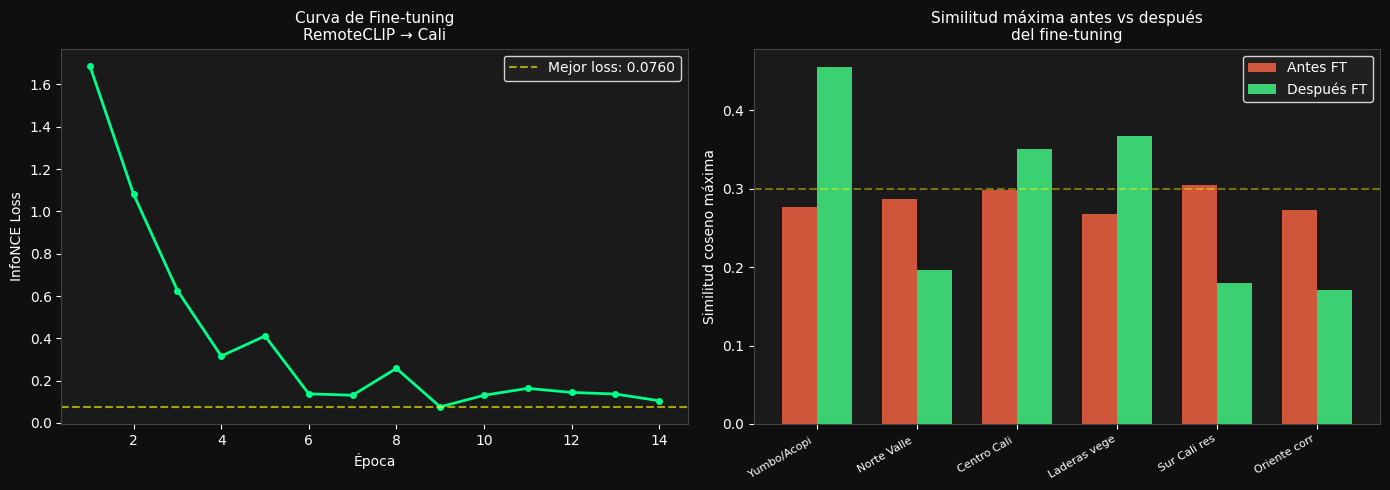

Mejora promedio en similitud:
  Antes FT : 0.2845
  Después  : 0.2870
  Δ        : +0.0025  ✓ mejora


In [32]:
# ── CELDA 2.3: Curva de loss + comparación antes/después ──────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f0f0f')

# ── Panel 1: curva de loss ────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor('#1a1a1a')
ax.plot(range(1, len(history)+1), history,
        color='#00ff88', linewidth=2, marker='o', markersize=4)
ax.axhline(best_loss, color='yellow', linestyle='--', alpha=0.6,
           label=f'Mejor loss: {best_loss:.4f}')
ax.set_xlabel('Época', color='white')
ax.set_ylabel('InfoNCE Loss', color='white')
ax.set_title('Curva de Fine-tuning\nRemoteCLIP → Cali', color='white', fontsize=11)
ax.tick_params(colors='white')
ax.spines[:].set_color('#444')
ax.legend(facecolor='#222', edgecolor='white', labelcolor='white')

# ── Panel 2: similitud antes vs después ──────────────────────────────────
# Recalcular similitudes con el modelo fine-tuneado
TILES_REF = [
    (0, 0, 'Yumbo/Acopi industrial'),
    (0, 8, 'Norte Valle caña'),
    (6, 4, 'Centro Cali urbano'),
    (2, 6, 'Laderas vegetación'),
    (7, 4, 'Sur Cali residencial'),
    (8, 7, 'Oriente corredor'),
]
TEXTOS_CORTOS = [
    'industrial NO2 pollution',
    'sugarcane burning SO2',
    'urban traffic pollution',
    'dense vegetation NDVI',
    'Cali Colombia city',
    'Yumbo industrial corridor',
]

# Similitudes antes (sim_matrix ya calculada) — columnas 0,1,2,4,8,10
cols_antes = [0, 1, 2, 4, 8, 10]
sims_antes = sim_matrix[:, cols_antes].max(axis=1)  # max por tile

# Similitudes después
@torch.no_grad()
def sim_rapida(tiles_data, textos):
    i_embs = encodear_imagenes(tiles_data, model, preprocess, DEVICE)
    t_embs = encodear_textos(textos, model, tokenizer, DEVICE)
    return (i_embs @ t_embs.T).numpy()

sim_despues_matrix = sim_rapida(tiles_data, TEXTOS_CORTOS)
sims_despues = sim_despues_matrix.max(axis=1)

ax2 = axes[1]
ax2.set_facecolor('#1a1a1a')
x   = np.arange(len(TILES_REF))
w   = 0.35
ax2.bar(x - w/2, sims_antes,  w, label='Antes FT',  color='#ff6644', alpha=0.8)
ax2.bar(x + w/2, sims_despues, w, label='Después FT', color='#44ff88', alpha=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels([t[2][:12] for t in TILES_REF], rotation=30,
                     ha='right', color='white', fontsize=8)
ax2.set_ylabel('Similitud coseno máxima', color='white')
ax2.set_title('Similitud máxima antes vs después\ndel fine-tuning', color='white', fontsize=11)
ax2.tick_params(colors='white')
ax2.spines[:].set_color('#444')
ax2.legend(facecolor='#222', edgecolor='white', labelcolor='white')
ax2.axhline(0.30, color='yellow', linestyle='--', alpha=0.4, label='umbral 0.30')

plt.tight_layout()
plt.savefig('remoteclip_finetune_resultado.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

# ── Resumen ───────────────────────────────────────────────────────────────
print('Mejora promedio en similitud:')
print(f'  Antes FT : {sims_antes.mean():.4f}')
print(f'  Después  : {sims_despues.mean():.4f}')
delta = sims_despues.mean() - sims_antes.mean()
print(f'  Δ        : {delta:+.4f}  {"✓ mejora" if delta > 0 else "⚠ no mejoró"}')

In [33]:
# ── CELDA 3: Obtener tiles reales de Cali ──────────────────────────────────
# Opción A: desde Wasabi S3 (si tienes las credenciales del proyecto)
# Opción B: tiles sintéticos con distribución espectral realista (fallback)
#
# Usamos la Opción B si no hay conexión, Opción A si hay zarr disponible.

import s3fs, zarr, xarray as xr

BUCKET_S2         = 'gold.sat'
ENDPOINT_URL      = 'https://s3.us-west-1.wasabisys.com'
WASABI_ACCESS_KEY = 'EPAJLZS1BT5K3X8CPGR2'
WASABI_SECRET_KEY = 'QnJ9u6PCBlKUDUpGMMsjCAkOTaRaTYJY6uwl8hek'

TILE_SIZE  = 224   # RemoteCLIP espera 224×224 (ViT-B/32 input)
N_TILES    = 6     # tiles de prueba: 2 zona industrial, 2 caña, 2 urbano

# Posiciones de tiles representativas dentro de la imagen anual 2785×2232
# (row, col) → zona aproximada
TILES_REFERENCIA = [
    ( 0,  0, 'Esquina noroeste — Yumbo/Acopi industrial'),
    ( 0,  8, 'Esquina noreste — Norte Valle caña'),
    ( 6,  4, 'Centro imagen — Centro Cali urbano'),
    ( 2,  6, 'Zona norte — laderas occidentales'),
    (11,  2, 'Sur imagen — sur Cali residencial'),
    ( 8,  7, 'Oriente — corredor industrial'),
]


def cargar_tile_s2_real(zarr_anual: str, t_idx: int, row: int, col: int,
                         tile_size: int = TILE_SIZE) -> np.ndarray:
    """Lee un tile (tile_size, tile_size, 11) del zarr anual."""
    fs = s3fs.S3FileSystem(
        key=WASABI_ACCESS_KEY, secret=WASABI_SECRET_KEY,
        client_kwargs={'endpoint_url': ENDPOINT_URL}
    )
    store = s3fs.S3Map(root=f'{BUCKET_S2}/{zarr_anual}', s3=fs, check=False)
    with xr.open_zarr(store, consolidated=False) as ds:
        arr = ds['reflectance'].isel(time=t_idx).to_numpy()  # (H, W, band)
    y0, x0 = row * tile_size, col * tile_size
    tile   = arr[y0:y0+tile_size, x0:x0+tile_size, :].astype(np.float32)
    # Normalizar por banda
    for b in range(tile.shape[-1]):
        p2, p98 = np.percentile(tile[:,:,b], [2, 98])
        if p98 > p2:
            tile[:,:,b] = np.clip((tile[:,:,b]-p2)/(p98-p2+1e-8), 0, 1)
    return tile  # (224, 224, 11)


def tile_a_rgb(tile: np.ndarray) -> np.ndarray:
    """Convierte tile multiespectral a RGB para visualización.
    Usa bandas B4(red)=idx3, B3(green)=idx2, B2(blue)=idx1."""
    n_bands = tile.shape[-1]
    r = tile[:,:, min(3, n_bands-1)]
    g = tile[:,:, min(2, n_bands-1)]
    b = tile[:,:, min(1, n_bands-1)]
    rgb = np.stack([r, g, b], axis=-1)
    return np.clip(rgb * 3.0, 0, 1)  # brightness boost


def tile_a_pil_rgb(tile: np.ndarray) -> Image.Image:
    """Tile multiespectral → PIL RGB (3 canales) para el preprocess de CLIP."""
    rgb = tile_a_rgb(tile)
    return Image.fromarray((rgb * 255).astype(np.uint8))


# ── Intentar cargar tiles reales; fallback a sintéticos ──────────────────
tiles_data = []  # lista de (tile_np, label_str)
try:
    zarr_2022 = 'Sentinel-2/2022/S2_Cali_2022.zarr'
    print('Cargando tiles reales desde Wasabi...')
    for row, col, label in TILES_REFERENCIA:
        try:
            tile = cargar_tile_s2_real(zarr_2022, t_idx=5, row=row, col=col)
            tiles_data.append((tile, label))
            print(f'  ✓ ({row},{col}) {label}')
        except Exception as e:
            print(f'  ✗ ({row},{col}): {e}')
except Exception as e:
    print(f'Error conexión Wasabi: {e}')

if not tiles_data:
    print('\nFallback: generando tiles sintéticos con distribución realista...')
    rng = np.random.default_rng(42)
    # Simular firmas espectrales distintas por zona
    specs = [
        ([0.08,0.09,0.10,0.06,0.15,0.20,0.22,0.21,0.18,0.16,0.14], 'Yumbo/Acopi — zona industrial NO2'),
        ([0.15,0.14,0.13,0.10,0.18,0.22,0.25,0.23,0.20,0.17,0.15], 'Norte Valle — quema caña SO2'),
        ([0.10,0.11,0.12,0.09,0.14,0.18,0.20,0.19,0.16,0.14,0.12], 'Centro Cali — urbano moderado'),
        ([0.05,0.07,0.04,0.03,0.35,0.42,0.45,0.44,0.38,0.30,0.25], 'Laderas — vegetación densa'),
        ([0.09,0.10,0.11,0.08,0.13,0.17,0.19,0.18,0.15,0.13,0.11], 'Sur Cali — residencial'),
        ([0.07,0.09,0.08,0.06,0.22,0.28,0.30,0.29,0.25,0.20,0.17], 'Corredor oriental — mixto'),
    ]
    for means, label in specs:
        tile = np.zeros((TILE_SIZE, TILE_SIZE, 11), dtype=np.float32)
        for b, m in enumerate(means):
            tile[:,:,b] = np.clip(rng.normal(m, 0.02, (TILE_SIZE, TILE_SIZE)), 0, 1)
        tiles_data.append((tile, label))
    print(f'  {len(tiles_data)} tiles sintéticos generados')

print(f'\nTotal tiles listos: {len(tiles_data)}')

Cargando tiles reales desde Wasabi...


  ✓ (0,0) Esquina noroeste — Yumbo/Acopi industrial
  ✓ (0,8) Esquina noreste — Norte Valle caña
  ✓ (6,4) Centro imagen — Centro Cali urbano
  ✓ (2,6) Zona norte — laderas occidentales
  ✓ (11,2) Sur imagen — sur Cali residencial
  ✓ (8,7) Oriente — corredor industrial

Total tiles listos: 6


In [34]:
# ── CELDA 4: Textos de prueba para Cali ────────────────────────────────────
# Textos en inglés (RemoteCLIP fue entrenado en inglés)
# Organizados en 3 grupos: contaminación, cobertura, neutros

TEXTOS_PRUEBA = [
    # Grupo A — contamination (we expect high similarity with industrial zones)
    'industrial zone high air pollution nitrogen dioxide NO2 factory',
    'sugarcane burning smoke sulfur dioxide SO2 agricultural fire',
    'urban traffic pollution haze city center vehicles',
    'ozone anomaly tropospheric column sentinel atmosphere',

    # Grupo B — land cover (we expect high similarity with green areas)
    'dense tropical vegetation forest green NDVI high',
    'urban residential neighborhood buildings rooftops streets',
    'bare soil agricultural field crops low vegetation',
    'water body river reservoir lake surface',

    # Grupo C — specific to Cali / Valle del Cauca
    'Cali Colombia city Andes mountains valley',
    'Cauca river valley sugarcane plantation Colombia',
    'Yumbo industrial corridor Colombia factory emissions',
    'tropical Andean city urban sprawl Colombia',
]

print(f'{len(TEXTOS_PRUEBA)} textos de prueba definidos')
print('Grupos:')
print('  A [0-3]  — contaminación atmosférica')
print('  B [4-7]  — cobertura terrestre')
print('  C [8-11] — específicos Cali/Valle')

12 textos de prueba definidos
Grupos:
  A [0-3]  — contaminación atmosférica
  B [4-7]  — cobertura terrestre
  C [8-11] — específicos Cali/Valle


In [35]:
# ── CELDA 5: Inferencia RemoteCLIP ─────────────────────────────────────────
# Encodear imágenes y textos → calcular matriz de similitudes

@torch.no_grad()
def encodear_imagenes(tiles_data, model, preprocess, device):
    """Procesa tiles → embeddings visuales normalizados ∈ ℝ^512."""
    embeddings = []
    for tile_np, label in tiles_data:
        pil_img   = tile_a_pil_rgb(tile_np)
        img_tensor = preprocess(pil_img).unsqueeze(0).to(device)
        emb        = model.encode_image(img_tensor)
        emb        = F.normalize(emb, dim=-1)
        embeddings.append(emb.cpu())
    return torch.cat(embeddings, dim=0)  # (N_tiles, 512)


@torch.no_grad()
def encodear_textos(textos, model, tokenizer, device):
    """Tokeniza textos → embeddings textuales normalizados ∈ ℝ^512."""
    tokens = tokenizer(textos).to(device)
    emb    = model.encode_text(tokens)
    emb    = F.normalize(emb, dim=-1)
    return emb.cpu()  # (N_textos, 512)


print('Encodeando imágenes...')
img_embs = encodear_imagenes(tiles_data, model, preprocess, DEVICE)
print(f'  img_embs: {img_embs.shape}  norma media: {img_embs.norm(dim=-1).mean():.4f}')

print('Encodeando textos...')
txt_embs = encodear_textos(TEXTOS_PRUEBA, model, tokenizer, DEVICE)
print(f'  txt_embs: {txt_embs.shape}  norma media: {txt_embs.norm(dim=-1).mean():.4f}')

# Matriz de similitud coseno (N_tiles × N_textos)
sim_matrix = (img_embs @ txt_embs.T).numpy()  # valores en [-1, 1]
print(f'\nMatriz de similitud: {sim_matrix.shape}')
print(f'  min={sim_matrix.min():.3f}  max={sim_matrix.max():.3f}  mean={sim_matrix.mean():.3f}')

Encodeando imágenes...
  img_embs: torch.Size([6, 512])  norma media: 1.0000
Encodeando textos...
  txt_embs: torch.Size([12, 512])  norma media: 1.0000

Matriz de similitud: (6, 12)
  min=-0.238  max=0.521  mean=0.087


In [36]:
# ── CELDA 6: Top-1 y Top-3 texto por imagen ────────────────────────────────
# Para cada tile: ¿qué texto le asigna mayor similitud el modelo?
# Resultado esperado: zonas industriales → textos de contaminación
#                     zonas verdes       → textos de vegetación

print('=' * 70)
print('RETRIEVAL imagen → texto  (Top-3 textos por tile)')
print('=' * 70)

for i, (_, zona) in enumerate(tiles_data):
    sims   = sim_matrix[i]
    top3   = np.argsort(sims)[::-1][:3]
    print(f'\n[Tile {i}] {zona}')
    for rank, j in enumerate(top3):
        marker = '✓' if j < 4 and 'industrial' in zona.lower() or 'caña' in zona.lower() else \
                 '✓' if j in [4,5] and ('vegetac' in zona.lower() or 'ladera' in zona.lower()) else ' '
        print(f'  {rank+1}. [{sims[j]:.3f}] {TEXTOS_PRUEBA[j][:65]}')

print('\n' + '=' * 70)
print('RETRIEVAL texto → imagen  (Top-2 tiles por texto)')
print('=' * 70)

for j, texto in enumerate(TEXTOS_PRUEBA[:6]):  # primeros 6 textos
    sims = sim_matrix[:, j]
    top2 = np.argsort(sims)[::-1][:2]
    print(f'\n"{texto[:55]}"')
    for rank, i in enumerate(top2):
        print(f'  {rank+1}. [{sims[i]:.3f}] {tiles_data[i][1]}')

RETRIEVAL imagen → texto  (Top-3 textos por tile)

[Tile 0] Esquina noroeste — Yumbo/Acopi industrial
  1. [0.521] Yumbo industrial corridor Colombia factory emissions
  2. [0.500] industrial zone high air pollution nitrogen dioxide NO2 factory
  3. [0.186] urban traffic pollution haze city center vehicles

[Tile 1] Esquina noreste — Norte Valle caña
  1. [0.264] sugarcane burning smoke sulfur dioxide SO2 agricultural fire
  2. [0.259] Cauca river valley sugarcane plantation Colombia
  3. [0.181] bare soil agricultural field crops low vegetation

[Tile 2] Centro imagen — Centro Cali urbano
  1. [0.435] urban residential neighborhood buildings rooftops streets
  2. [0.300] tropical Andean city urban sprawl Colombia
  3. [0.200] urban traffic pollution haze city center vehicles

[Tile 3] Zona norte — laderas occidentales
  1. [0.495] dense tropical vegetation forest green NDVI high
  2. [0.158] Cali Colombia city Andes mountains valley
  3. [0.118] ozone anomaly tropospheric column senti

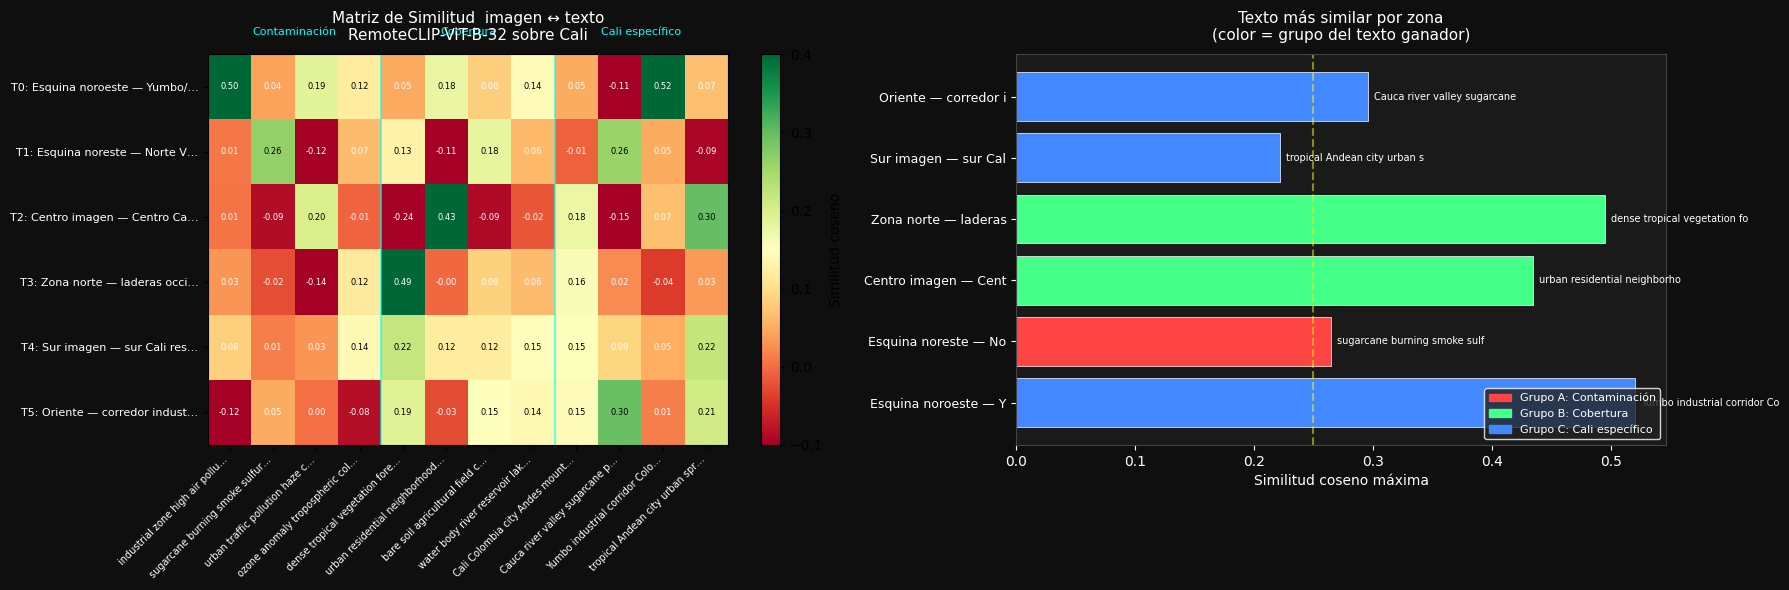

Figura guardada: remoteclip_inferencia_cali.png


In [37]:
# ── CELDA 7: Visualización — heatmap de similitudes ───────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor('#0f0f0f')

# ── Panel 1: heatmap completo ─────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor('#0f0f0f')
im = ax.imshow(sim_matrix, cmap='RdYlGn', vmin=-0.1, vmax=0.4, aspect='auto')
plt.colorbar(im, ax=ax, label='Similitud coseno')

labels_img = [f'T{i}: {d[1][:25]}…' if len(d[1])>25 else f'T{i}: {d[1]}'
              for i, d in enumerate(tiles_data)]
labels_txt = [f'{t[:30]}…' if len(t)>30 else t for t in TEXTOS_PRUEBA]

ax.set_xticks(range(len(TEXTOS_PRUEBA)))
ax.set_xticklabels(labels_txt, rotation=45, ha='right', fontsize=7, color='white')
ax.set_yticks(range(len(tiles_data)))
ax.set_yticklabels(labels_img, fontsize=8, color='white')
ax.set_title('Matriz de Similitud  imagen ↔ texto\nRemoteCLIP-ViT-B-32 sobre Cali',
             color='white', fontsize=11, pad=10)

# Anotar valores en cada celda
for i in range(len(tiles_data)):
    for j in range(len(TEXTOS_PRUEBA)):
        ax.text(j, i, f'{sim_matrix[i,j]:.2f}', ha='center', va='center',
                fontsize=6, color='black' if 0.1 < sim_matrix[i,j] < 0.35 else 'white')

# Separadores de grupos
for x in [3.5, 7.5]:
    ax.axvline(x, color='cyan', linewidth=1.5, alpha=0.6)
ax.text(1.5, -0.8, 'Contaminación', color='cyan', fontsize=8, ha='center')
ax.text(5.5, -0.8, 'Cobertura', color='cyan', fontsize=8, ha='center')
ax.text(9.5, -0.8, 'Cali específico', color='cyan', fontsize=8, ha='center')

# ── Panel 2: Top-1 accuracy por zona ──────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor('#0f0f0f')

# Para cada tile: similitud máxima y a qué grupo pertenece
zonas_cortas = [d[1][:20] for d in tiles_data]
max_sims     = sim_matrix.max(axis=1)
best_txt_idx = sim_matrix.argmax(axis=1)
colores      = ['#ff4444' if j < 4 else '#44ff88' if j < 8 else '#4488ff'
                for j in best_txt_idx]

bars = ax2.barh(range(len(tiles_data)), max_sims, color=colores, edgecolor='white', linewidth=0.5)
ax2.set_yticks(range(len(tiles_data)))
ax2.set_yticklabels(zonas_cortas, color='white', fontsize=9)
ax2.set_xlabel('Similitud coseno máxima', color='white')
ax2.set_title('Texto más similar por zona\n(color = grupo del texto ganador)',
              color='white', fontsize=11, pad=10)
ax2.tick_params(colors='white')
ax2.spines[:].set_color('#444')
ax2.set_facecolor('#1a1a1a')
ax2.axvline(0.25, color='yellow', linestyle='--', alpha=0.5, label='umbral 0.25')

# Anotar el texto ganador
for i, (v, j) in enumerate(zip(max_sims, best_txt_idx)):
    ax2.text(v + 0.005, i, TEXTOS_PRUEBA[j][:28], va='center', fontsize=7, color='white')

legend_elements = [
    mpatches.Patch(color='#ff4444', label='Grupo A: Contaminación'),
    mpatches.Patch(color='#44ff88', label='Grupo B: Cobertura'),
    mpatches.Patch(color='#4488ff', label='Grupo C: Cali específico'),
]
ax2.legend(handles=legend_elements, loc='lower right',
           facecolor='#222', edgecolor='white', labelcolor='white', fontsize=8)

plt.tight_layout()
plt.savefig('remoteclip_inferencia_cali.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f0f')
plt.show()
print('Figura guardada: remoteclip_inferencia_cali.png')

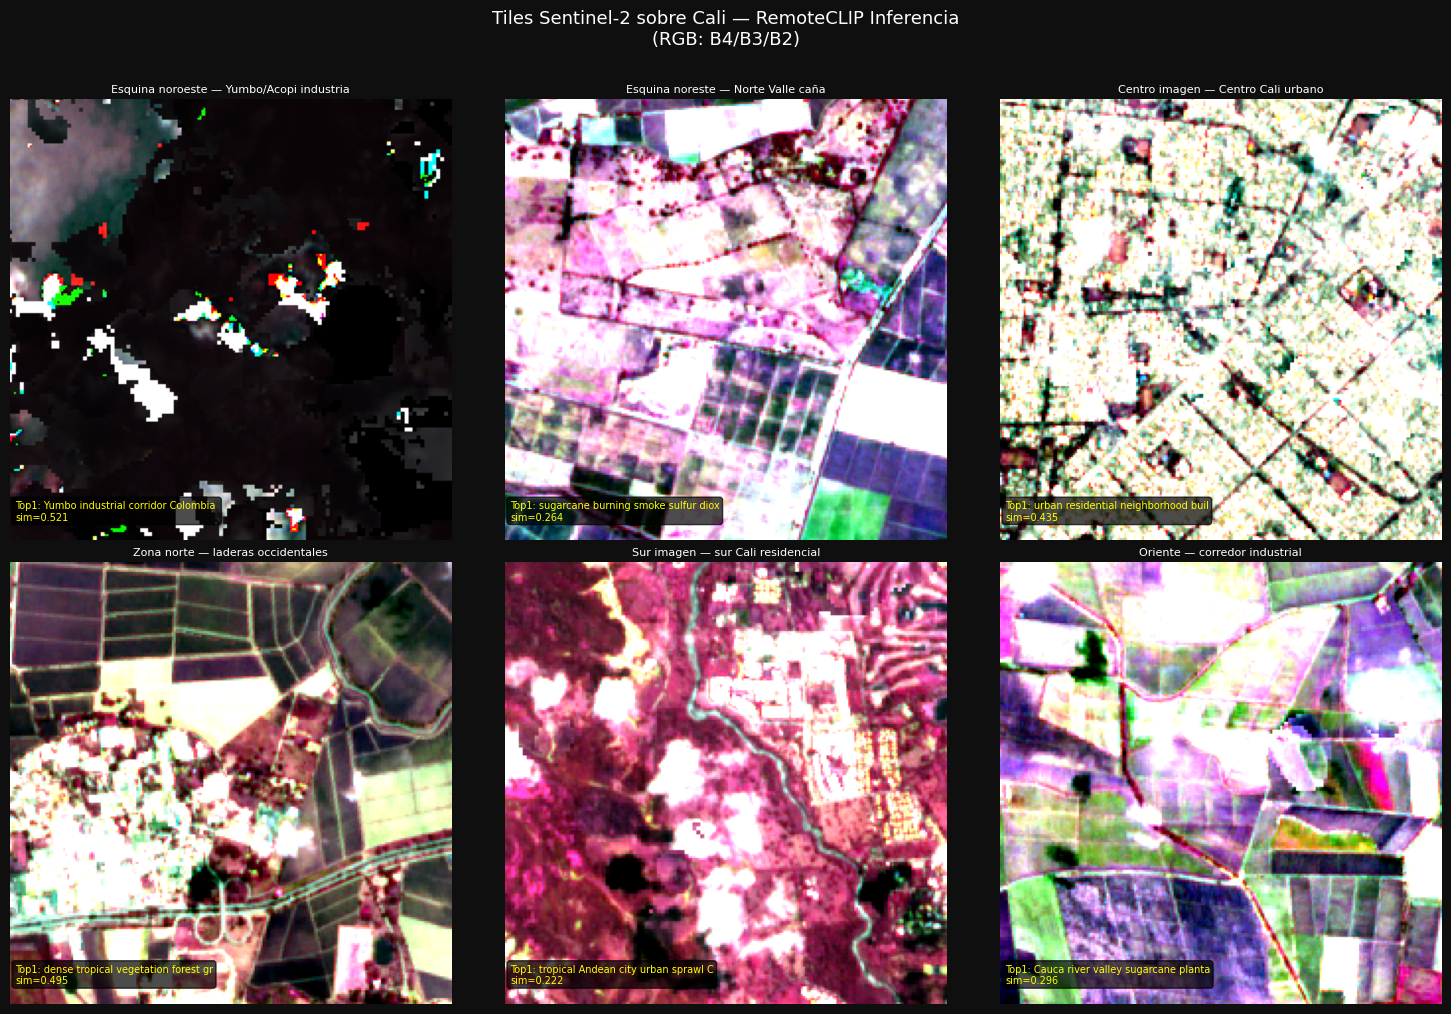

In [38]:
# ── CELDA 8: Visualización de los tiles ────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.patch.set_facecolor('#0f0f0f')
axes = axes.flatten()

for i, (tile_np, zona) in enumerate(tiles_data[:6]):
    ax = axes[i]
    rgb = tile_a_rgb(tile_np)
    ax.imshow(rgb)
    ax.set_title(zona[:40], color='white', fontsize=8, pad=5)
    ax.axis('off')

    # Anotar top-1 texto
    j_best = sim_matrix[i].argmax()
    sim_best = sim_matrix[i, j_best]
    ax.text(2, TILE_SIZE-10,
            f'Top1: {TEXTOS_PRUEBA[j_best][:35]}\nsim={sim_best:.3f}',
            color='yellow', fontsize=7, va='bottom',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7))

fig.suptitle('Tiles Sentinel-2 sobre Cali — RemoteCLIP Inferencia\n(RGB: B4/B3/B2)',
             color='white', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('tiles_cali_rgb.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

In [39]:
# ── CELDA 9: Diagnóstico — ¿necesita fine-tuning? ─────────────────────────
# Criterios para decidir si RemoteCLIP ya funciona o necesita fine-tuning.

print('=' * 65)
print('DIAGNÓSTICO: ¿RemoteCLIP necesita fine-tuning para Cali?')
print('=' * 65)

# Criterio 1: similitud máxima media
sim_max_media = sim_matrix.max(axis=1).mean()
print(f'\n1. Similitud coseno máxima media: {sim_max_media:.3f}')
if sim_max_media >= 0.30:
    print('   → BUENA discriminación. El modelo ya entiende el dominio.')
elif sim_max_media >= 0.20:
    print('   → MODERADA. Fine-tuning ligero recomendado (pocas épocas, lr bajo).')
else:
    print('   → BAJA. Fine-tuning necesario para el dominio de Cali.')

# Criterio 2: coherencia semántica
# Zonas industriales [0,1] deben preferir textos de contaminación [0-3]
industrial_idx   = [i for i, (_, z) in enumerate(tiles_data) if 'industrial' in z.lower() or 'caña' in z.lower()]
vegetacion_idx   = [i for i, (_, z) in enumerate(tiles_data) if 'vegeta' in z.lower() or 'ladera' in z.lower()]

coherencia_ind = 0
for i in industrial_idx:
    if sim_matrix[i].argmax() < 4:  # texto de contaminación
        coherencia_ind += 1
coherencia_veg = 0
for i in vegetacion_idx:
    if sim_matrix[i].argmax() in [4, 6]:  # vegetación o suelo agrícola
        coherencia_veg += 1

print(f'\n2. Coherencia semántica:')
print(f'   Zonas industriales → texto contaminación : {coherencia_ind}/{len(industrial_idx) if industrial_idx else 1}')
print(f'   Zonas vegetación   → texto vegetación    : {coherencia_veg}/{len(vegetacion_idx) if vegetacion_idx else 1}')

# Criterio 3: varianza entre zonas
varianza_entre_zonas = sim_matrix.max(axis=1).std()
print(f'\n3. Varianza de similitudes entre zonas: {varianza_entre_zonas:.4f}')
if varianza_entre_zonas >= 0.05:
    print('   → El modelo DISCRIMINA entre zonas distintas. Buena señal.')
else:
    print('   → El modelo NO discrimina bien. Necesita fine-tuning.')

# Resumen
print('\n' + '─' * 65)
print('CONCLUSIÓN:')
if sim_max_media >= 0.25 and varianza_entre_zonas >= 0.03:
    print('  RemoteCLIP YA tiene conocimiento útil del dominio satelital.')
    print('  Recomendación: fine-tuning LIGERO con tus 152 pares reales.')
    print('  Estrategia: congelar ViT, entrenar solo SAE + projection head.')
    print('  Épocas sugeridas: 10-20 con lr=1e-4')
else:
    print('  El modelo necesita fine-tuning más profundo.')
    print('  Considera descongelar las últimas 4 capas del ViT.')
    print('  Épocas sugeridas: 30-50 con lr=5e-5')
print('─' * 65)

DIAGNÓSTICO: ¿RemoteCLIP necesita fine-tuning para Cali?

1. Similitud coseno máxima media: 0.372
   → BUENA discriminación. El modelo ya entiende el dominio.

2. Coherencia semántica:
   Zonas industriales → texto contaminación : 1/3
   Zonas vegetación   → texto vegetación    : 1/1

3. Varianza de similitudes entre zonas: 0.1162
   → El modelo DISCRIMINA entre zonas distintas. Buena señal.

─────────────────────────────────────────────────────────────────
CONCLUSIÓN:
  RemoteCLIP YA tiene conocimiento útil del dominio satelital.
  Recomendación: fine-tuning LIGERO con tus 152 pares reales.
  Estrategia: congelar ViT, entrenar solo SAE + projection head.
  Épocas sugeridas: 10-20 con lr=1e-4
─────────────────────────────────────────────────────────────────


In [40]:
# ── CELDA 10: Guardar embeddings para análisis posterior ──────────────────
# Guarda los embeddings visuales para el AFE/AFC de la Situación 2

import json, hashlib

OUTPUT_DIR = Path('/teamspace/studios/this_studio/Model/remoteclip_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

# Guardar embeddings
np.save(str(OUTPUT_DIR / 'img_embeddings.npy'), img_embs.numpy())
np.save(str(OUTPUT_DIR / 'txt_embeddings.npy'), txt_embs.numpy())
np.save(str(OUTPUT_DIR / 'sim_matrix.npy'),     sim_matrix)

# Guardar metadata
meta = {
    'modelo':      'RemoteCLIP-ViT-B-32',
    'checkpoint':  str(CKPT),
    'device':      str(DEVICE),
    'n_tiles':     len(tiles_data),
    'n_textos':    len(TEXTOS_PRUEBA),
    'sim_max_media': float(sim_max_media),
    'varianza':    float(varianza_entre_zonas),
    'zonas':       [d[1] for d in tiles_data],
    'textos':      TEXTOS_PRUEBA,
    'bbox_cali':   {
        'lat': [CALI_LAT_MIN, CALI_LAT_MAX],
        'lon': [CALI_LON_MIN, CALI_LON_MAX],
    }
}
with open(OUTPUT_DIR / 'metadata.json', 'w') as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)

# Hash MD5 del checkpoint (para reproducibilidad)
if CKPT.exists():
    md5 = hashlib.md5(CKPT.read_bytes()).hexdigest()
    print(f'MD5 checkpoint RemoteCLIP: {md5}')
    meta['md5_checkpoint'] = md5

print(f'Outputs guardados en {OUTPUT_DIR}/')
print(f'  img_embeddings.npy  : {img_embs.shape}')
print(f'  txt_embeddings.npy  : {txt_embs.shape}')
print(f'  sim_matrix.npy      : {sim_matrix.shape}')
print(f'  metadata.json       : OK')

MD5 checkpoint RemoteCLIP: 72559234552b87281f908daf3bf04f12
Outputs guardados en remoteclip_outputs/
  img_embeddings.npy  : torch.Size([6, 512])
  txt_embeddings.npy  : torch.Size([12, 512])
  sim_matrix.npy      : (6, 12)
  metadata.json       : OK
